# Machine Learning : Prédiction des durées moyennes de séjour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1.1 Chargement du dataset

In [2]:
df = pd.read_excel("../DATA/INPUT/donnees_hopital_ML.xlsx")
df.head()

,nb_lits,nb_personnel_soignant,taux_occupation_moyen,taux_urgence,indice_gravite_patients,taux_readmission,nb_specialites,score_satisfaction,nb_accidents_zone,distance_hopital_principal,taux_chomage_zone,densite_population_zone,anciennete_moyenne_patients,nb_operations_mensuelles,capacite_urgences,duree_moyenne_sejour
0,152,228,89.638954,54.389051,2.919125,24.842666,27,3.908212,44,41.180619,18.046448,780,56.079970,278,21.0,6.32
1,485,157,90.687794,79.861557,3.323029,10.677091,8,2.663190,61,35.049236,15.957445,2624,69.724282,311,74.0,7.44
2,398,68,92.911614,65.144187,2.086748,12.183021,22,4.935192,43,27.092142,14.715698,2220,74.218827,904,51.0,7.32
3,320,158,89.768466,62.418828,2.593150,12.676943,27,4.244576,50,22.993801,16.943609,5360,47.239071,333,71.0,7.78
4,156,296,87.241577,66.714316,1.366797,14.316256,10,3.673440,60,5.135227,16.310346,4457,53.092174,564,20.0,6.26


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nb_lits                      300 non-null    int64  
 1   nb_personnel_soignant        300 non-null    int64  
 2   taux_occupation_moyen        300 non-null    float64
 3   taux_urgence                 300 non-null    float64
 4   indice_gravite_patients      300 non-null    float64
 5   taux_readmission             300 non-null    float64
 6   nb_specialites               300 non-null    int64  
 7   score_satisfaction           300 non-null    float64
 8   nb_accidents_zone            300 non-null    int64  
 9   distance_hopital_principal   300 non-null    float64
 10  taux_chomage_zone            300 non-null    float64
 11  densite_population_zone      300 non-null    int64  
 12  anciennete_moyenne_patients  300 non-null    float64
 13  nb_operations_mensue

## 1.2 Taille du dataset

In [4]:
print("Taille du dataset:", df.shape)

Taille du dataset: (300, 16)


## 1.3 Statistiques descriptives + visualisations

In [5]:
df.describe().round(1)

,nb_lits,nb_personnel_soignant,taux_occupation_moyen,taux_urgence,indice_gravite_patients,taux_readmission,nb_specialites,score_satisfaction,nb_accidents_zone,distance_hopital_principal,taux_chomage_zone,densite_population_zone,anciennete_moyenne_patients,nb_operations_mensuelles,capacite_urgences,duree_moyenne_sejour
count,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,295.0,297.0
mean,277.9,166.2,80.2,50.9,3.0,14.8,17.1,3.5,55.2,25.5,12.8,4816.0,56.6,541.9,55.8,6.5
std,125.3,75.0,11.3,16.9,1.2,5.4,7.2,0.9,25.2,14.3,4.3,2841.6,13.8,263.7,26.2,0.8
min,51.0,30.0,60.1,20.0,1.0,5.0,5.0,2.0,10.0,1.1,5.0,118.0,30.3,100.0,10.0,4.3
25%,177.8,104.0,70.7,37.6,2.0,10.1,11.0,2.7,34.0,12.7,9.1,2337.5,47.3,318.5,32.5,6.0
50%,275.0,171.5,81.2,51.6,3.1,14.6,17.5,3.5,55.0,26.2,13.1,4677.0,57.2,522.0,57.0,6.5
75%,389.0,223.0,89.6,65.2,4.1,18.7,24.0,4.2,76.2,38.0,16.6,7369.2,67.6,798.0,77.0,7.0
max,498.0,298.0,99.9,80.0,5.0,24.9,29.0,5.0,99.0,50.0,20.0,9965.0,79.5,998.0,99.0,9.1


**Les statistiques descriptives nous permettent d'observer l'ordre de grandeur et la dispersion des variables :**  






| Variable | Interprétation rapide |
|:---|:---|
| nb_lits | En moyenne, les hôpitaux disposent de 278 lits. Cela varie entre 51 et 498 lits selon la taille de l'établissement. |
| nb_personnel_soignant | En moyenne, 166 personnels soignants par hôpital, avec des écarts allant de 30 à près de 300. |
| taux_occupation_moyen | Le taux moyen d'occupation est élevé (80 %) avec une dispersion raisonnable entre 60 % et 100 %. |
| taux_urgence | Environ 51 % des patients arrivent par les urgences, avec une large variabilité entre 20 % et 80 %. |
| indice_gravite_patients | L'indice moyen de gravité est de 3, sur une échelle de 1 à 5, ce qui indique des patients modérément graves. |
| taux_readmission | Le taux de réadmission est en moyenne de 15 %, ce qui est cohérent pour un réseau hospitalier généraliste. |
| nb_specialites | En moyenne, les établissements proposent 17 spécialités médicales, avec un minimum de 5 et un maximum de 29. |
| score_satisfaction | Le score moyen est de 3,5/5, ce qui est globalement satisfaisant. |
| nb_accidents_zone | En moyenne, 55 accidents sont recensés dans la zone desservie, avec des variations importantes entre 10 et 99. |
| distance_hopital_principal | Distance moyenne de 25,5 km par rapport au principal hôpital régional, allant de 1 km à 50 km. |
| taux_chomage_zone | Taux de chômage moyen de 12,8 % avec des écarts régionaux notables entre 5 % et 20 %. |
| densite_population_zone | Forte variabilité de la densité, allant de 118 habitants/km² à près de 10 000 habitants/km². |
| anciennete_moyenne_patients | L'âge moyen des patients est d'environ 56,6 ans, ce qui est réaliste pour un hôpital généraliste. |
| nb_operations_mensuelles | Le nombre moyen d'opérations réalisées par mois est de 542, avec une forte dispersion selon la taille de l’établissement. |
| capacite_urgences | Capacité moyenne d'accueil aux urgences de 56 places, avec des valeurs comprises entre 10 et 99. |
| duree_moyenne_sejour | La durée moyenne de séjour est de 6,5 jours, ce qui correspond aux standards hospitaliers en France. |  





> Les valeurs sont globalement cohérentes. Aucune statistique n’indique de problème majeur dans la distribution des variables.


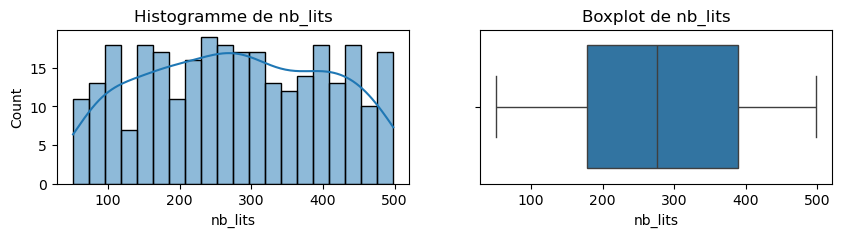

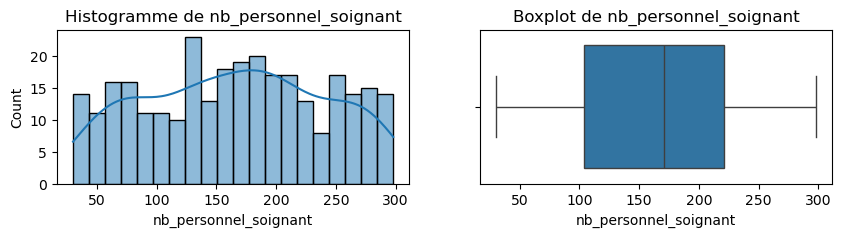

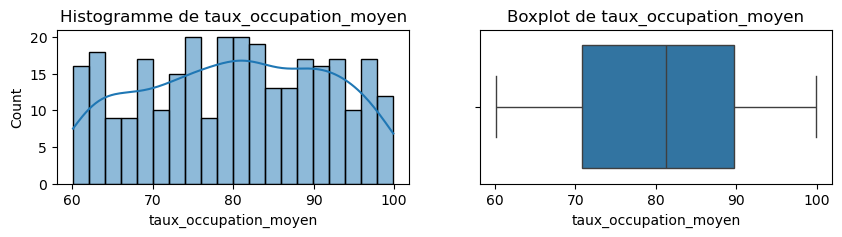

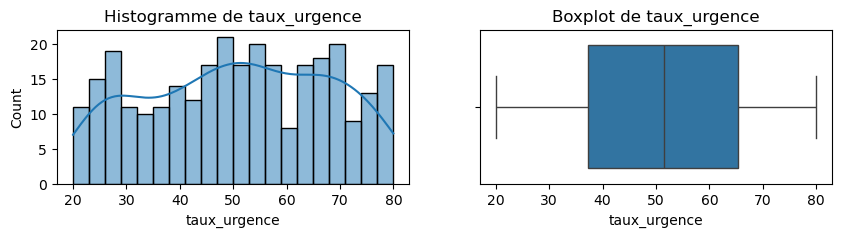

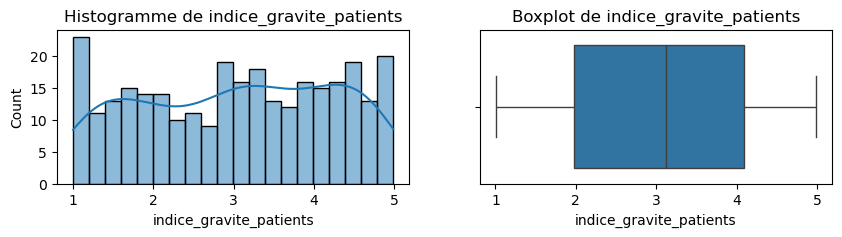

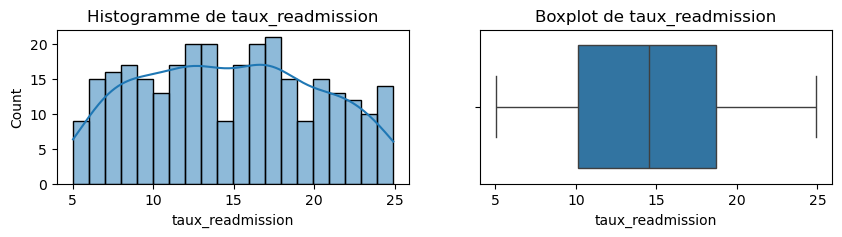

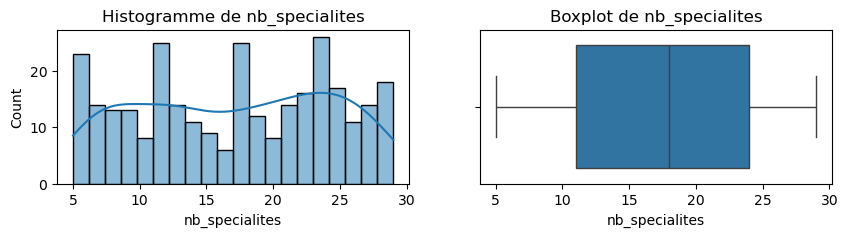

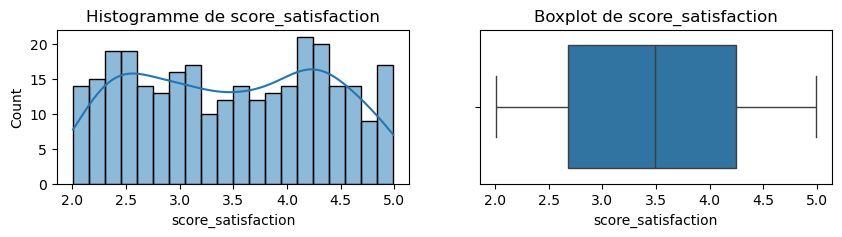

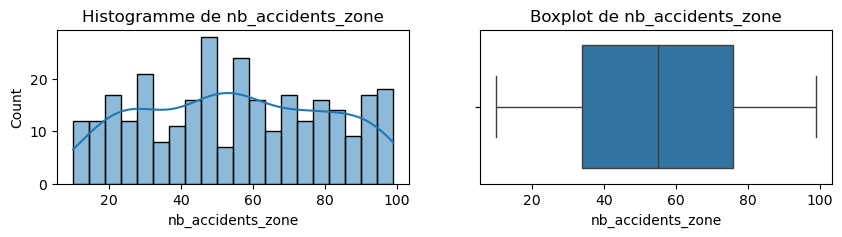

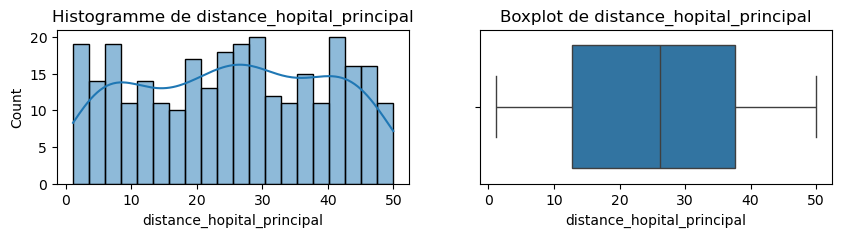

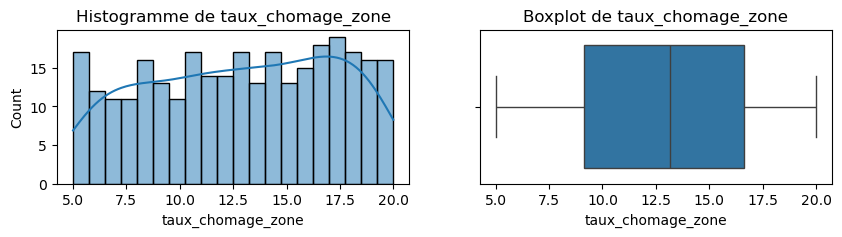

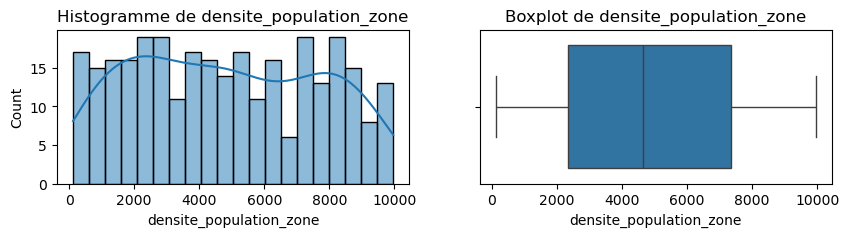

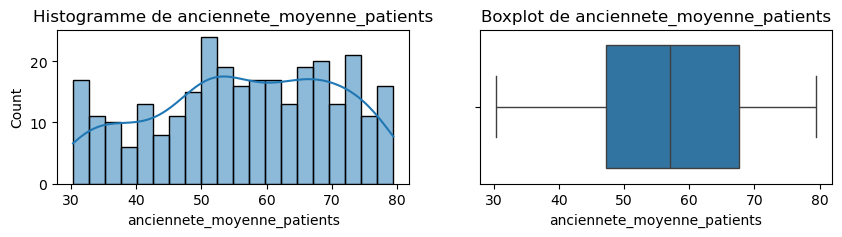

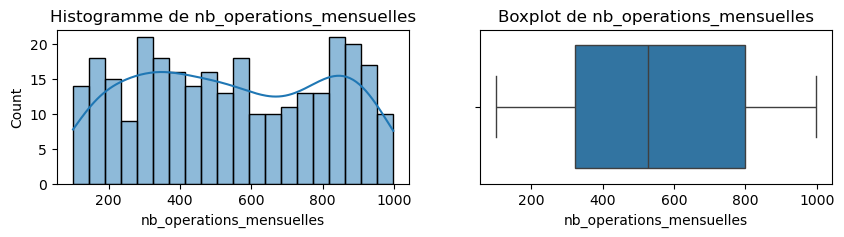

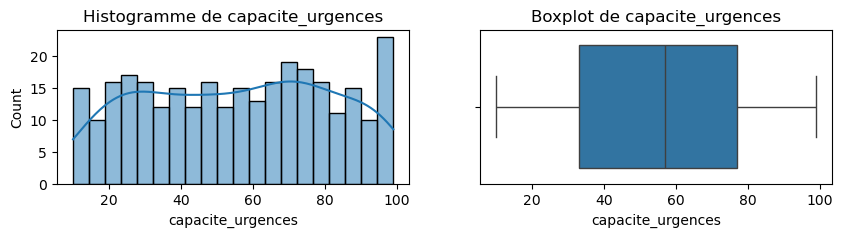

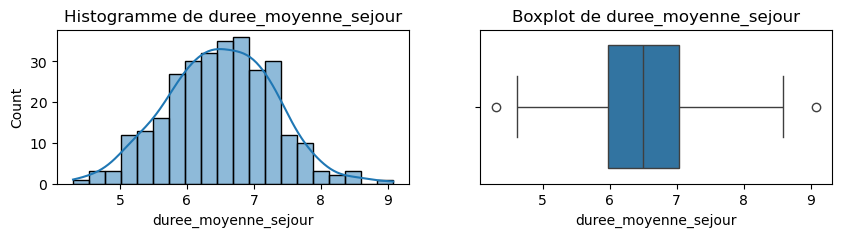

In [19]:
variables = df.columns
for var in variables:
    plt.figure(figsize=(10,2))
    plt.subplot(1,2,1)
    sns.histplot(df[var], bins=20, kde=True)
    plt.title(f"Histogramme de {var}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    
    plt.show()

| Variable | Interprétation rapide |
|:---|:---|
| nb_lits | La plupart des hôpitaux ont entre 100 et 400 lits. Les valeurs plus élevées correspondent à de très gros établissements. |
| nb_personnel_soignant | Distribution équilibrée. Plus de personnel dans les grands hôpitaux, ce qui est cohérent. |
| taux_occupation_moyen | Taux d’occupation généralement élevé entre 70 % et 95 %. Pas d'anomalie. |
| taux_urgence | Variabilité logique selon la spécialisation de l'hôpital. Pas d'anomalie. |
| indice_gravite_patients | Gravité moyenne correcte, principalement entre 2 et 4 sur 5. Cohérent. |
| taux_readmission | Taux de réadmission inférieur à 20 % dans la majorité des cas. Pas d'alerte. |
| nb_specialites | La plupart des hôpitaux offrent entre 10 et 25 spécialités. Répartition logique. |
| score_satisfaction | Scores de satisfaction globalement supérieurs à 3,5/5. Réaliste. |
| nb_accidents_zone | Plus d'accidents dans certaines zones urbaines. Variation attendue. |
| distance_hopital_principal | Majorité des hôpitaux situés à moins de 20 km d’un centre principal. Cohérent. |
| taux_chomage_zone | Taux de chômage entre 6 % et 18 %, variation régionale normale. |
| densite_population_zone | Zones très denses et zones rurales représentées. Répartition cohérente. |
| anciennete_moyenne_patients | Âge moyen des patients entre 40 et 75 ans, conforme au secteur hospitalier. |
| nb_operations_mensuelles | Activité chirurgicale stable entre 200 et 800 opérations par mois, quelques pics normaux. |
| capacite_urgences | Capacité d’accueil des urgences comprise entre 30 et 80 places, selon la taille de l’hôpital. |

L’analyse des boxplots ne met pas en évidence de valeurs aberrantes nécessitant une suppression. Les valeurs extrêmes observées restent cohérentes avec les plages des variables et sont donc conservées.

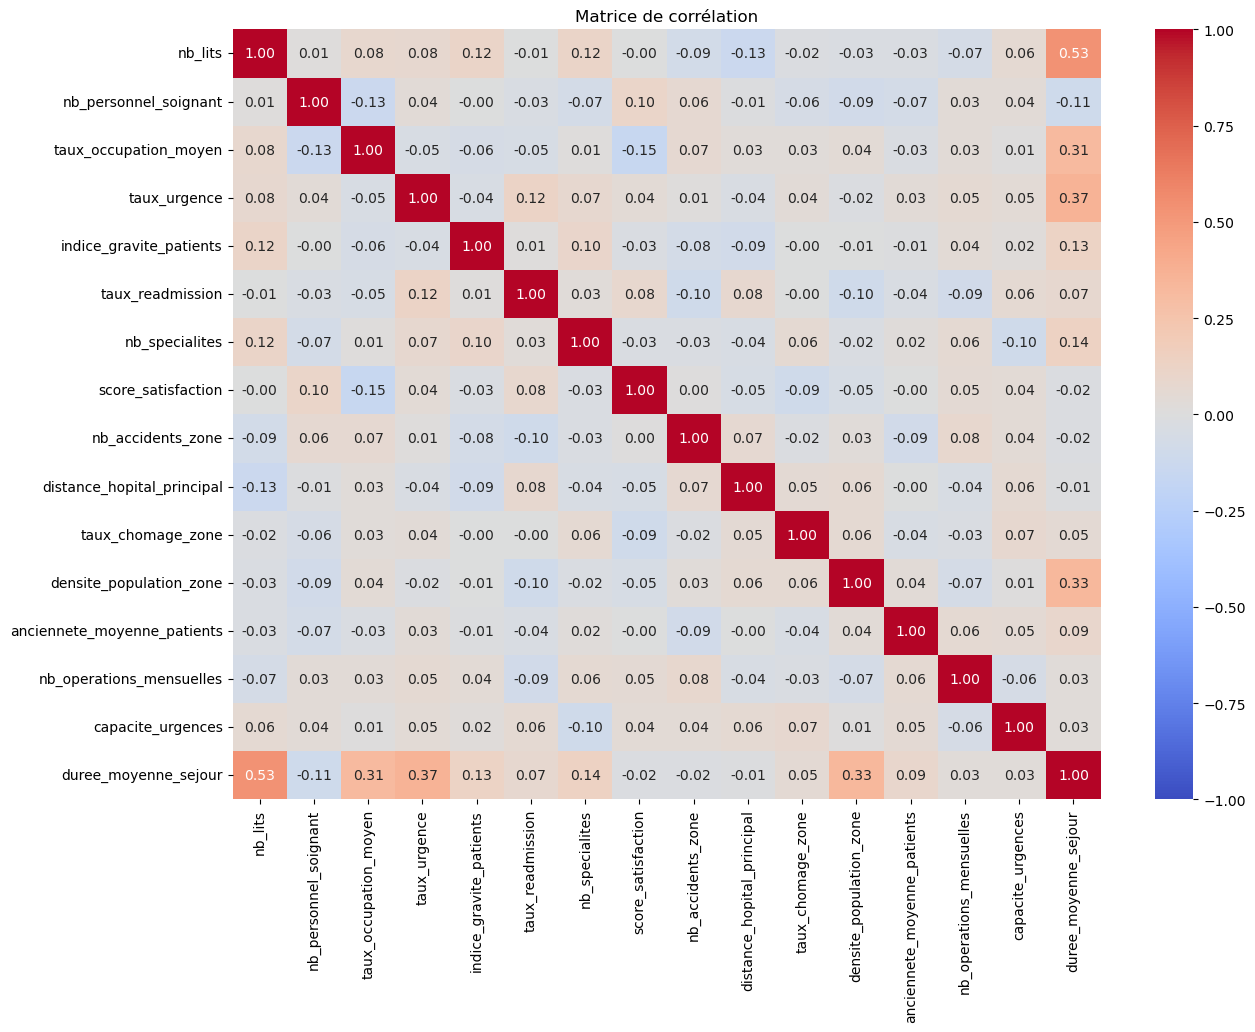


Corrélations avec Durée de séjour:

duree_moyenne_sejour           1.000000
nb_lits                        0.534946
taux_urgence                   0.367040
densite_population_zone        0.328364
taux_occupation_moyen          0.314234
nb_specialites                 0.136080
indice_gravite_patients        0.125651
anciennete_moyenne_patients    0.091444
taux_readmission               0.073866
taux_chomage_zone              0.047678
capacite_urgences              0.028585
nb_operations_mensuelles       0.027374
distance_hopital_principal    -0.014996
nb_accidents_zone             -0.019498
score_satisfaction            -0.022675
nb_personnel_soignant         -0.105312
Name: duree_moyenne_sejour, dtype: float64


In [7]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matrice de corrélation")
plt.show()

print("\nCorrélations avec Durée de séjour:\n")
print(df.corr()['duree_moyenne_sejour'].sort_values(ascending=False))

- La variable nb_lits présente la corrélation la plus forte avec la durée moyenne de séjour (0,53). Plus l'hôpital dispose de lits, plus les séjours tendent à être longs.

- taux_urgence est modérément corrélé (0,37) : les hôpitaux qui accueillent davantage de patients par les urgences ont des séjours plus longs en moyenne.

- densite_population_zone est aussi modérément corrélée (0,33) : les hôpitaux situés dans des zones densément peuplées semblent avoir des séjours légèrement plus longs.

- taux_occupation_moyen montre également une corrélation positive (0,31) : un hôpital très occupé tend à avoir des séjours plus longs.

Les autres variables présentent des corrélations beaucoup plus faibles :
- nb_specialites (0,14) et indice_gravite_patients (0,13) sont faiblement corrélées positivement à la durée de séjour.
- anciennete_moyenne_patients (0,09) et taux_readmission (0,07) ont une très faible corrélation.
- taux_chomage_zone, capacite_urgences, nb_operations_mensuelles, distance_hopital_principal, nb_accidents_zone et score_satisfaction ont un impact négligeable.
- nb_personnel_soignant est faiblement corrélé négativement (-0,10) avec la durée de séjour.



> Les principales variables expliquant la durée moyenne de séjour sont nb_lits, taux_urgence, densite_population_zone et taux_occupation_moyen.  
Les autres variables peuvent être conservées pour enrichir l'analyse mais auront un impact limité sur les prédictions.

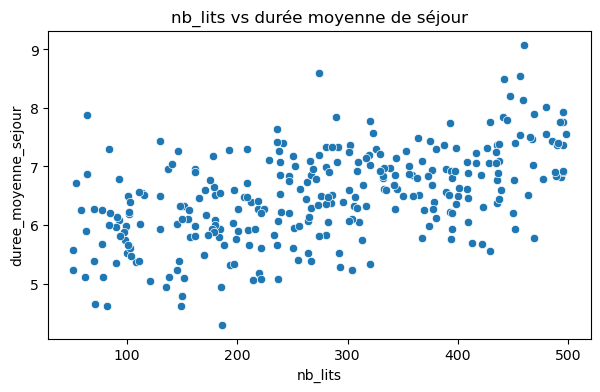

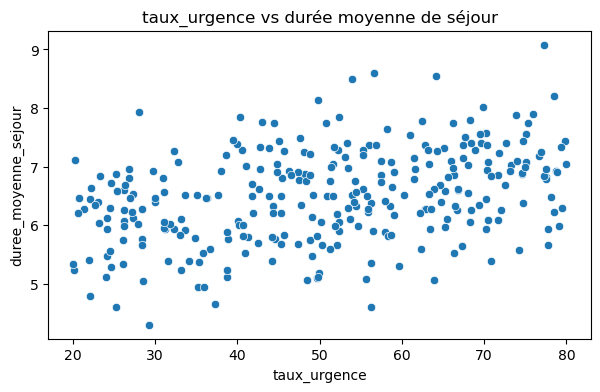

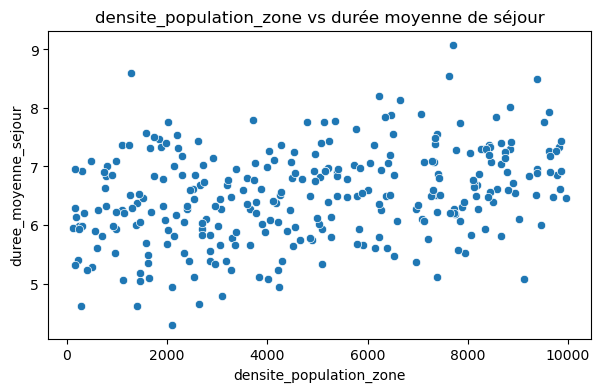

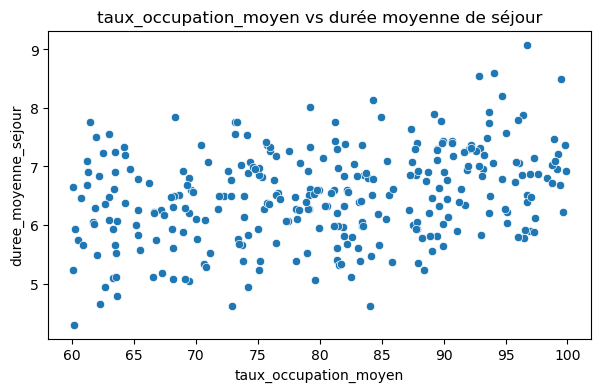

In [8]:
variables_corr = [
    "nb_lits",
    "taux_urgence",
    "densite_population_zone",
    "taux_occupation_moyen"
]

for var in variables_corr:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        x=df[var],
        y=df["duree_moyenne_sejour"]
    )
    plt.title(f"{var} vs durée moyenne de séjour")
    plt.show()


Les scatter plots confirment les résultats de la matrice de corrélation. Le nombre de lits présente la tendance linéaire positive la plus visible avec la durée moyenne de séjour. Les relations avec le taux d’urgence, la densité de population et le taux d’occupation sont positives mais plus dispersées.

# 2. Nettoyage et préparation des données

In [9]:
df.isnull().sum()

nb_lits                        0
nb_personnel_soignant          0
taux_occupation_moyen          0
taux_urgence                   0
indice_gravite_patients        0
taux_readmission               0
nb_specialites                 0
score_satisfaction             0
nb_accidents_zone              0
distance_hopital_principal     0
taux_chomage_zone              0
densite_population_zone        0
anciennete_moyenne_patients    0
nb_operations_mensuelles       0
capacite_urgences              5
duree_moyenne_sejour           3
dtype: int64

In [10]:
df[df.isnull().any(axis=1)]

,nb_lits,nb_personnel_soignant,taux_occupation_moyen,taux_urgence,indice_gravite_patients,taux_readmission,nb_specialites,score_satisfaction,nb_accidents_zone,distance_hopital_principal,taux_chomage_zone,densite_population_zone,anciennete_moyenne_patients,nb_operations_mensuelles,capacite_urgences,duree_moyenne_sejour
168,228,129,88.820642,64.501217,4.040376,18.401921,10,4.483605,85,39.876307,8.807316,7917,62.735454,290,NaN,NaN
169,112,283,62.493655,61.930751,2.769195,23.592118,14,4.363139,54,49.536756,8.687112,2193,71.188370,521,NaN,NaN
170,401,251,65.909564,44.153003,2.247808,15.645204,25,3.873276,76,10.831900,11.041466,7171,33.157015,219,NaN,NaN
253,103,138,78.926648,23.095748,3.212006,18.602639,13,2.506563,55,47.081977,7.866781,7929,61.582176,112,NaN,6.40
293,492,155,73.312631,43.037833,3.352234,9.547146,27,4.457765,79,1.141181,6.473525,9528,55.078785,882,NaN,7.76


In [11]:
df = df.dropna(subset=["duree_moyenne_sejour"])

df["capacite_urgences"] = df["capacite_urgences"].fillna(
    df["capacite_urgences"].median()
)

Les lignes où la durée moyenne de séjour est manquante sont supprimées car il s’agit de la variable à prédire. Les valeurs manquantes de capacite_urgences sont remplacées par la médiane afin de conserver les observations concernées.

In [12]:
df.isnull().sum()

nb_lits                        0
nb_personnel_soignant          0
taux_occupation_moyen          0
taux_urgence                   0
indice_gravite_patients        0
taux_readmission               0
nb_specialites                 0
score_satisfaction             0
nb_accidents_zone              0
distance_hopital_principal     0
taux_chomage_zone              0
densite_population_zone        0
anciennete_moyenne_patients    0
nb_operations_mensuelles       0
capacite_urgences              0
duree_moyenne_sejour           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

### Séparation des données

In [14]:
X = df.drop(columns=["duree_moyenne_sejour"])
y = df["duree_moyenne_sejour"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Construction du modèle de régression linéaire multiple

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

df_coeffs = pd.DataFrame({
    'Variables': X.columns,
    'Coefficients': model.coef_
})
print(df_coeffs.sort_values(by='Coefficients', key=abs, ascending=False))


                      Variables  Coefficients
4       indice_gravite_patients      0.070647
7            score_satisfaction      0.027160
2         taux_occupation_moyen      0.019971
3                  taux_urgence      0.014879
5              taux_readmission      0.009387
12  anciennete_moyenne_patients      0.006214
6                nb_specialites      0.004763
0                       nb_lits      0.003134
9    distance_hopital_principal      0.002378
10            taux_chomage_zone      0.001942
14            capacite_urgences     -0.001038
1         nb_personnel_soignant     -0.000555
8             nb_accidents_zone      0.000242
11      densite_population_zone      0.000095
13     nb_operations_mensuelles      0.000088


# Interprétation des coefficients du modèle

Chaque coefficient représente l'effet d'une variable sur la durée moyenne de séjour, en maintenant les autres variables constantes ("toute chose égale par ailleurs").

- Une augmentation d'une unité de l'<span style="color:blue;">indice_gravite_patients</span> entraîne une augmentation de <span style="color:green;">0,071 jour (≈ 1,70 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'une unité du <span style="color:blue;">score_satisfaction</span> entraîne une augmentation de <span style="color:green;">0,027 jour (≈ 0,65 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'un point du <span style="color:blue;">taux_occupation_moyen</span> entraîne une augmentation de <span style="color:green;">0,020 jour (≈ 0,48 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'un point du <span style="color:blue;">taux_urgence</span> entraîne une augmentation de <span style="color:green;">0,015 jour (≈ 0,36 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'un point du <span style="color:blue;">taux_readmission</span> entraîne une augmentation de <span style="color:green;">0,009 jour (≈ 0,23 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'une année de l'<span style="color:blue;">anciennete_moyenne_patients</span> entraîne une augmentation de <span style="color:green;">0,006 jour (≈ 0,15 heure)</span> de la durée moyenne de séjour.
- Une spécialité médicale supplémentaire (<span style="color:blue;">nb_specialites</span>) entraîne une augmentation de <span style="color:green;">0,005 jour (≈ 0,11 heure)</span> de la durée moyenne de séjour.
- Un lit supplémentaire (<span style="color:blue;">nb_lits</span>) entraîne une augmentation de <span style="color:green;">0,003 jour (≈ 0,08 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'un kilomètre de la <span style="color:blue;">distance_hopital_principal</span> entraîne une augmentation de <span style="color:green;">0,002 jour (≈ 0,06 heure)</span> de la durée moyenne de séjour.
- Une augmentation d'un point du <span style="color:blue;">taux_chomage_zone</span> entraîne une augmentation de <span style="color:green;">0,002 jour (≈ 0,05 heure)</span> de la durée moyenne de séjour.
- Une place supplémentaire en <span style="color:blue;">capacite_urgences</span> entraîne une diminution de <span style="color:red;">0,001 jour (≈ 0,02 heure)</span> de la durée moyenne de séjour.
- Un personnel soignant supplémentaire (<span style="color:blue;">nb_personnel_soignant</span>) entraîne une diminution de <span style="color:red;">0,0006 jour (≈ 0,01 heure)</span> de la durée moyenne de séjour.
- Un accident supplémentaire dans la zone (<span style="color:blue;">nb_accidents_zone</span>) entraîne une augmentation très faible de <span style="color:green;">0,0002 jour</span> de la durée moyenne de séjour.
- Une opération mensuelle supplémentaire (<span style="color:blue;">nb_operations_mensuelles</span>) entraîne une augmentation négligeable de <span style="color:green;">0,00009 jour</span> de la durée moyenne de séjour.
- Une augmentation de 100 habitants/km² de la <span style="color:blue;">densite_population_zone</span> entraîne une augmentation d'environ <span style="color:green;">0,010 jour (≈ 0,23 heure)</span> de la durée moyenne de séjour.

> Les coefficients montrent que plusieurs variables sont associées à une variation de la durée moyenne de séjour, notamment l'indice de gravité des patients, le score de satisfaction, le taux d'occupation et le taux d'urgence. Cependant, les variables étant exprimées dans des unités différentes, la valeur brute des coefficients ne permet pas à elle seule de déterminer quelles variables sont les plus influentes.

# 4. Évaluation du modèle

RMSE : 0.46
R2 : 0.6634
MSE : 0.21
Intercept : 1.9151053816729613


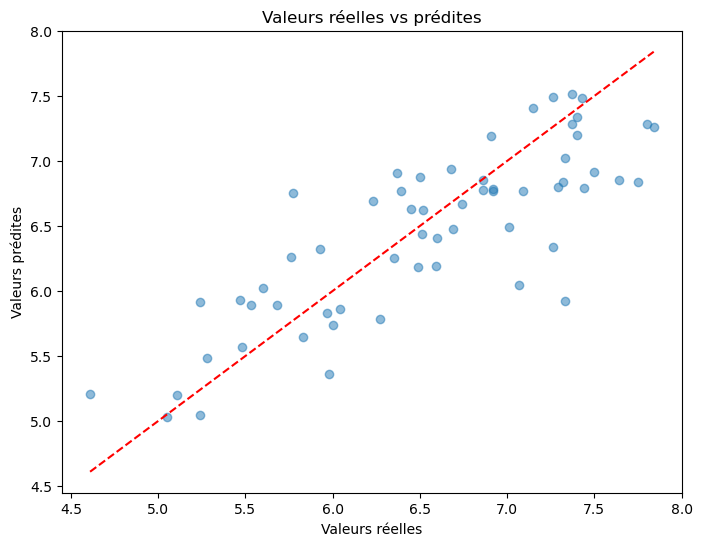

In [17]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")
print(f"MSE : {mse:.2f}")
print("Intercept :", model.intercept_)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs prédites")
plt.show()

Sur le graphique, les points sont globalement répartis autour de la droite représentant les prédictions parfaites. Une partie des points se trouve au-dessus de la droite : le modèle a donc surestimé certaines valeurs. D’autres points se trouvent en dessous : le modèle a sous-estimé certaines valeurs. Les écarts semblent globalement assez équilibrés. On peut donc dire que le modèle donne des résultats corrects, mais qu’il n’est pas parfait.

**Analyse :**
> Chaque point bleu représente un hôpital : son abscisse est la durée moyenne de séjour réelle et son ordonnée est la durée moyenne de séjour prédite. La ligne rouge en pointillés représente la situation idéale : si tous les points étaient parfaitement sur cette ligne, cela signifierait que les prédictions du modèle seraient parfaites.

**Évaluation chiffrée :**

- **R² = 0,6634** : le modèle explique environ 66 % des variations de la durée moyenne de séjour.
- **MSE = 0,21** : cette mesure indique l'importance moyenne des erreurs au carré entre les valeurs réelles et les valeurs prédites.
- **RMSE = 0,46 jour** : l'erreur de prédiction est de l'ordre de 0,46 jour, soit environ 11 heures.

Le modèle de régression linéaire multiple donne de bonnes performances sur ces données hospitalières. Il peut aider pour prédire la durée moyenne de séjour avec une précision correcte, même s'il reste quelques marges d'erreur à améliorer avec des modèles plus complexes ou un enrichissement des données.

# 5. Application du modèle sur les nouvelles données

In [18]:
df_new = pd.read_excel("../DATA/INPUT/nouvelles_donnees_hopital.xlsx")

predictions_new = model.predict(df_new)
df_new['duree_moyenne_sejour_predite'] = predictions_new.round(2)
df_new.to_excel("../DATA/OUTPUT/predictions_hopital.xlsx", index=False)
print("\n Fichier 'predictions_hopital.xlsx' généré avec succès !")


 Fichier 'predictions_hopital.xlsx' généré avec succès !


### Conclusion

Le modèle de régression linéaire multiple obtient un R² de 0,663. Il explique donc environ 66 % des variations de la durée moyenne de séjour. Les prédictions sont globalement proches des valeurs réelles, même si des écarts restent présents. Le modèle donne donc des résultats corrects mais reste perfectible et ne doit pas être utilisé comme seul élément pour une décision stratégique.